<h1><strong><center> Результаты </center></strong></h1>

## 1. Рассмотрим кластеры

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import pairwise_distances

In [2]:
file_path = "../../data/data_for_final_models/AgglomerativeClustering_generated_features.csv"
df = pd.read_csv(file_path)

In [3]:
cluster_column = 'Cluster'
feature_columns = df.drop(columns=[cluster_column]).columns

In [4]:
def find_closest_points(df, cluster_column, feature_columns, n_closest=1):
    '''
    Функция для поиска ближайших точек к центру масс кластера
    Параметры:
        df (pd.DataFrame): исходный датафрейм
        cluster_column (str): название колонки с кластерами
        feature_columns (list of str): названия колонок с признаками
        n_closest (int): количество ближайших точек
    Возвращает:
        pd.DataFrame: датафрейм с ближайшими точками к центру масс кластера
    '''
    closest_points = []
    for cluster in df[cluster_column].unique():
        cluster_data = df[df[cluster_column] == cluster]
        cluster_features = cluster_data[feature_columns]
        
        # Вычисляем центр масс
        centroid = cluster_features.mean().values.reshape(1, -1)
        
        # Вычисляем расстояния от каждой точки к центру масс
        distances = pairwise_distances(cluster_features, centroid)
        
        # Получаем индексы ближайших точек
        closest_indices = np.argsort(distances.flatten())[:n_closest]
        
        # Добавляем выбранные строки в итоговый список
        closest_points.append(cluster_data.iloc[closest_indices])
    
    return pd.concat(closest_points)

In [5]:
closest_samples = find_closest_points(df, cluster_column, feature_columns)
closest_samples.iloc[:, :18]

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,BALANCE_minus_BALANCE
5959,-0.619275,0.116261,0.117917,0.262948,0.493442,-0.937995,-0.060672,-0.372966,0.051266,-0.731294,-0.817031,0.021537,0.508252,-0.179564,-0.530722,-0.124591,0.341918,0.0
6058,0.771381,0.116261,-1.686076,-0.995909,-1.095968,1.356730,-1.317061,-0.740342,-0.968008,0.795790,0.768576,-1.389871,0.074628,-0.170842,0.366442,-0.569563,-0.285032,0.0
6793,0.854301,0.484620,0.405113,0.782211,0.472942,0.963001,0.340532,-0.032825,0.051266,0.681694,1.231620,0.280241,-0.112766,0.018517,0.575820,-0.569563,0.341918,0.0


#### Информация о признаках (перевод с английского):

1. **Balance** — Остаток на счете.  

2. **Balance Frequency** — Частота обновления остатка на счете.  

3. **Purchases** — Общая сумма покупок.  

4. **One-off Purchases** — Сумма разовых покупок.  

5. **Installment Purchases** — Сумма покупок в рассрочку.  

6. **Cash Advance** — Сумма снятия наличных.  

7. **Purchases Frequency** — Частота покупок.  

8. **One-off Purchases Frequency** — Частота разовых покупок.  

9. **Purchases Installments Frequency** — Частота покупок в рассрочку.  

10. **Cash Advance Frequency** — Частота снятия наличных.  

11. **Cash Advance TRX** — Количество операций снятия наличных.  

12. **Purchases TRX** — Количество операций покупок.  

13. **Credit Limit** — Кредитный лимит.  

14. **Payments** — Общая сумма платежей.  

15. **Minimum Payments** — Минимальная сумма платежей.  

16. **PRC Full payment** — Процент полного погашения задолженности.  

17. **Tenure** — Срок обслуживания клиента (в месяцах). 

### Выводы:
1. **Первый кластер** (ID 5959):
   - **Баланс**: Низкий отрицательный баланс (-0.62), что может свидетельствовать о том, что клиент часто использует кредитный лимит, но не в больших объемах.
   - **Частота покупок**: Средняя (0.12), показывая умеренную активность.
   - **Сумма покупок**: Средняя (0.12), что указывает на сбалансированную покупательскую активность.
   - **Типы покупок**: Значительная доля покупок в рассрочку (0.49), что означает предпочтение платежей в рассрочку.
   - **Снятие наличных**: Очень низкая активность (-0.94), клиент не использует наличные.
   - **Процент полного погашения**: Низкий (-0.53), вероятно, клиент не делает полные выплаты, что увеличивает долговую нагрузку.
   
   **Маркетинговая стратегия**: Банку стоит предложить дополнительные продукты для клиентов, которые часто используют рассрочку, но не снимают наличные. Например, предложить персонализированные предложения на улучшение условий рассрочки или лояльности, а также направить информацию о том, как выгодно погашать баланс полностью.

2. **Второй кластер** (ID 6058):
   - **Баланс**: Положительный баланс (0.77), клиент активно использует кредит.
   - **Частота покупок**: Средняя (0.12), как и в первом случае, но с большими затратами.
   - **Сумма покупок**: Отрицательная (−1.69), что указывает на сильное снижение покупок.
   - **Типы покупок**: Покупки в рассрочку и снятие наличных имеют более низкие значения, что может означать, что клиент предпочитает более обычные покупки, а не рассрочку.
   - **Процент полного погашения**: Более высокое значение (0.37), что указывает на более здоровое финансовое поведение.
   
   **Маркетинговая стратегия**: Для такого клиента можно предложить премиум-услуги или бонусы за активное использование карты, например, программы лояльности с бонусами для возврата средств или на большие покупки.

3. **Третий кластер** (ID 6793):
   - **Баланс**: Положительный баланс (0.85), клиент более активно использует кредит.
   - **Частота покупок**: Умеренная (0.48), указывает на более высокую покупательскую активность.
   - **Сумма покупок**: Средняя (0.40), что указывает на баланс между покупками и платежами.
   - **Типы покупок**: Высокая доля разовых покупок (0.78), с меньшей долей покупок в рассрочку.
   - **Снятие наличных**: Вижу умеренную активность (0.96) — клиент может часто снимать наличные.
   - **Процент полного погашения**: Средний (-0.57), что может свидетельствовать о нечастых полных погашениях.
   
   **Маркетинговая стратегия**: Для этого сегмента рекомендуется продвигать продукты, направленные на улучшение финансового контроля, например, персонализированные предложения на снятие наличных с низкими процентами, или специальные программы для тех, кто часто делает разовые покупки.

### Заключение:

- **Первый сегмент** можно считать более осторожным, предпочитающим рассрочку и не использующим наличные. Маркетинг должен быть ориентирован на лояльность и улучшение условий рассрочки.
- **Второй сегмент** имеет более здоровые финансовые привычки с хорошим балансом, что предполагает возможность предложения премиум-продуктов и бонусов.
- **Третий сегмент** — это клиент с высокой покупательской активностью и предпочтением разовых покупок. Этот сегмент можно стимулировать предложениями на снятие наличных и дополнительными скидками.

## 2. Точность предсказаний моделей

Для дальнейшей сегментации клиентов без использования кластеризации были обучены модели классификации. Для оценки качества моделей была использована метрика balanced accuracy в связи с дисбалансом классов. По итогам обучения по итогу были достигнуты следующие результаты:

1. После Optuna:
- CatBoost - 0.9954
- LogisticRegression - 0.9919
- RandomForest - 0.9954
- GradientBoosting - 0.9953

2. С параметрами по умолчанию:
- ExtraTreesClassifier - 0.9936

После блендинга моделей с XGBoost в виде мета-модели был получен результат 0.9997

#### **Таким образом, точность предсказаний составила 99.97%**

## 3. Важные признаки

### Permutation Importance (CatBoost)

In [6]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import catboost
from tqdm import tqdm
from sklearn.inspection import permutation_importance
import warnings

warnings.filterwarnings('error')
warnings.filterwarnings('ignore')

In [7]:
file_path = '../../data/data_for_final_models/AgglomerativeClustering_generated_features.csv'
data = pd.read_csv(file_path)

X = data.drop(columns='Cluster')
y = data['Cluster']

In [8]:
def load_model(path):
    '''
    Функция для загрузки модели из файла
    Параметры:
        path (str): путь к файлу
    Возвращает:
        object: модель
    '''
    with open(path, 'rb') as file:
        return pickle.load(file)

gradient_boosting_model = load_model('../../models/3_final_models/optuna_gradient_boosting_model.pkl')
logistic_regression_model = load_model('../../models/3_final_models/optuna_logistic_regression_model.pkl')
random_forest_model = load_model('../../models/3_final_models/optuna_random_forest_model.pkl')
extra_trees_model = load_model('../../models/3_final_models/et_model.pkl')
meta_model = load_model('../../models/3_final_models/meta_model_xgboost.pkl')

catboost_model = catboost.CatBoostClassifier()
catboost_model.load_model('../../models/3_final_models/catboost_model.cb');

In [9]:
base_model_predictions = np.column_stack([
    gradient_boosting_model.predict_proba(X)[:, 1],
    logistic_regression_model.predict_proba(X)[:, 1],
    random_forest_model.predict_proba(X)[:, 1],
    extra_trees_model.predict_proba(X)[:, 1],
    catboost_model.predict_proba(X)[:, 1]
])

In [10]:
base_models = {
    'catboost': catboost_model,
    'lr': logistic_regression_model,
    'rf': random_forest_model,
    'et': extra_trees_model,
    'gb': gradient_boosting_model
}

In [11]:
feature_importances = {}

for model_name, model in tqdm(base_models.items()):
    # Среднее Permutation Importance для каждой модели
    perm_importance = permutation_importance(
        model, X, y, scoring='balanced_accuracy', n_repeats=5, random_state=42
    )
    feature_importances[model_name] = perm_importance.importances_mean

100%|██████████| 5/5 [5:12:02<00:00, 3744.56s/it]  


In [12]:
feature_importance_df = pd.DataFrame(feature_importances, index=X.columns)
feature_importance_df['mean_importance'] = feature_importance_df.mean(axis=1) # считаем среднее важности признака

sorted_importance = feature_importance_df.sort_values(by='mean_importance', ascending=False)

In [17]:
top_features = sorted_importance.head(10)

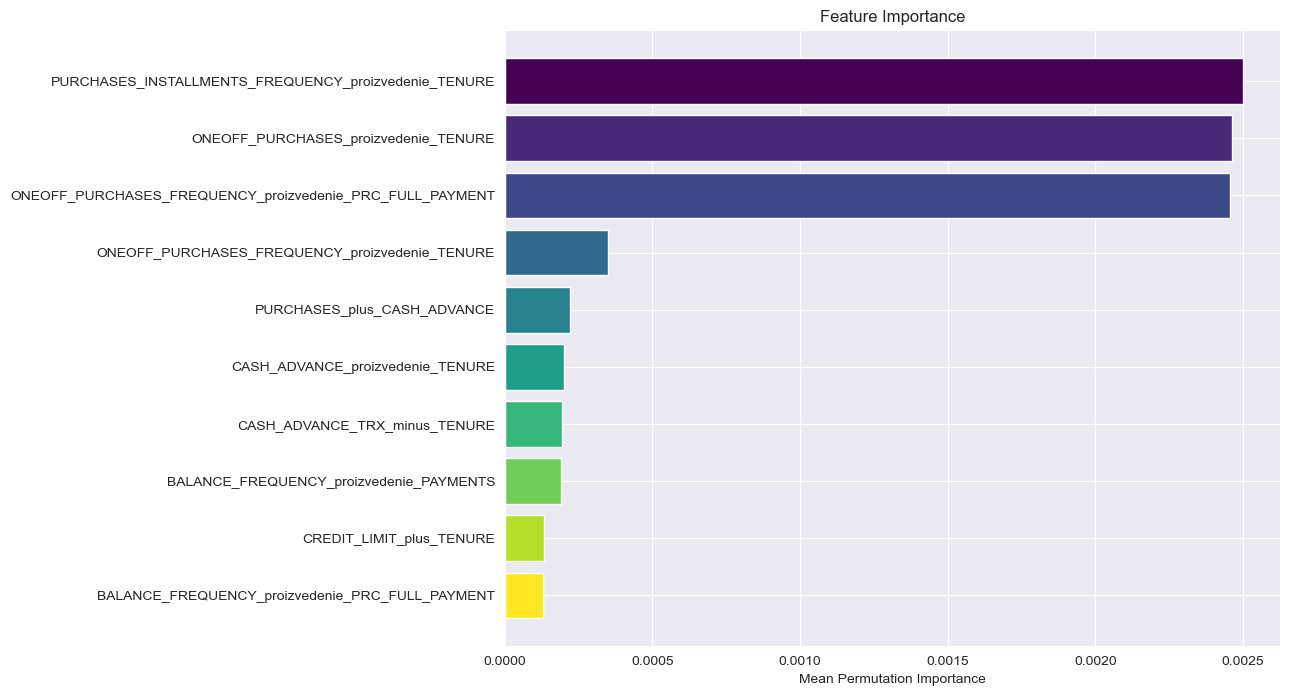

In [22]:
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features))) # цвета для графика

plt.figure(figsize=(10, 8))
plt.barh(top_features.index, top_features['mean_importance'], align='center', color=colors)
plt.xlabel('Mean Permutation Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()